In [1]:
# import libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure
%matplotlib inline
matplotlib.rcParams['figure.figsize']=(12,8)

#reading the data
df= pd.read_csv(r"C:\Users\Tanusree\Downloads\movies.csv.zip")



In [2]:
#  checking data
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [3]:
# checking the missing data
for col in df.columns:
    pct_missing=np.mean(df[col].isnull())
    print('{}-{}%'. format(col,round(pct_missing*100)))


name-0%
rating-1%
genre-0%
year-0%
released-0%
score-0%
votes-0%
director-0%
writer-0%
star-0%
country-0%
budget-28%
gross-2%
company-0%
runtime-0%


In [4]:
print (df.dtypes)

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object


In [5]:
# correct_year
df['correctyear']=df['released'].astype(str).str[8:13]
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctyear
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0,"23, 2"
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0,"7, 2"
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN,", 202"
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0,"1, 20"


In [6]:
df.shape

(7668, 16)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         7668 non-null   object 
 1   rating       7591 non-null   object 
 2   genre        7668 non-null   object 
 3   year         7668 non-null   int64  
 4   released     7666 non-null   object 
 5   score        7665 non-null   float64
 6   votes        7665 non-null   float64
 7   director     7668 non-null   object 
 8   writer       7665 non-null   object 
 9   star         7667 non-null   object 
 10  country      7665 non-null   object 
 11  budget       5497 non-null   float64
 12  gross        7479 non-null   float64
 13  company      7651 non-null   object 
 14  runtime      7664 non-null   float64
 15  correctyear  7668 non-null   object 
dtypes: float64(5), int64(1), object(10)
memory usage: 958.6+ KB


In [8]:
df.describe()

,year,score,votes,budget,gross,runtime
count,7668.000000,7665.000000,7.665000e+03,5.497000e+03,7.479000e+03,7664.000000
mean,2000.405451,6.390411,8.810850e+04,3.558988e+07,7.850054e+07,107.261613
std,11.153508,0.968842,1.633238e+05,4.145730e+07,1.657251e+08,18.581247
min,1980.000000,1.900000,7.000000e+00,3.000000e+03,3.090000e+02,55.000000
25%,1991.000000,5.800000,9.100000e+03,1.000000e+07,4.532056e+06,95.000000
50%,2000.000000,6.500000,3.300000e+04,2.050000e+07,2.020576e+07,104.000000
75%,2010.000000,7.100000,9.300000e+04,4.500000e+07,7.601669e+07,116.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,366.000000


In [9]:
df.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime', 'correctyear'],
      dtype='object')

In [10]:
for col in df.columns:
    pct_missing =np.mean(df[col].isnull())
    print(col,round(pct_missing*100))

name 0
rating 1
genre 0
year 0
released 0
score 0
votes 0
director 0
writer 0
star 0
country 0
budget 28
gross 2
company 0
runtime 0
correctyear 0


In [11]:
df=df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [12]:
type(df)

pandas.core.frame.DataFrame

In [13]:
pd.to_numeric(df['budget'],errors='coerce')

0       19000000.0
1        4500000.0
2       18000000.0
3        3500000.0
4        6000000.0
           ...    
7663        7000.0
7664           NaN
7665       58750.0
7666       15000.0
7667           NaN
Name: budget, Length: 7668, dtype: float64

In [14]:
pd.to_numeric(df['gross'],errors='coerce')

0        46998772.0
1        58853106.0
2       538375067.0
3        83453539.0
4        39846344.0
           ...     
7663            NaN
7664            NaN
7665            NaN
7666            NaN
7667            NaN
Name: gross, Length: 7668, dtype: float64

In [15]:
df=df.dropna(subset=['budget','gross'])

In [16]:
df.sort_values(by=['gross'],inplace=False,ascending=False)

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctyear
5445,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000.0,James Cameron,James Cameron,Sam Worthington,United States,237000000.0,2.847246e+09,Twentieth Century Fox,162.0,"18,"
7445,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000.0,2.797501e+09,Marvel Studios,181.0,", 201"
3045,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000.0,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000.0,2.201647e+09,Twentieth Century Fox,194.0,"19,"
6663,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000.0,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000.0,2.069522e+09,Lucasfilm,138.0,"18,"
7244,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000.0,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000.0,2.048360e+09,Marvel Studios,149.0,", 201"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2434,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900.0,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000.0,2.970000e+03,Trimark Pictures,97.0,1994
3681,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000.0,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000.0,2.554000e+03,Copperheart Entertainment,108.0,2001
272,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300.0,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000.0,2.270000e+03,Embassy Pictures,85.0,", 198"
2417,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100.0,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000.0,5.960000e+02,DENTSU Music And Entertainment,134.0,", 199"


In [17]:
df=df.drop_duplicates()

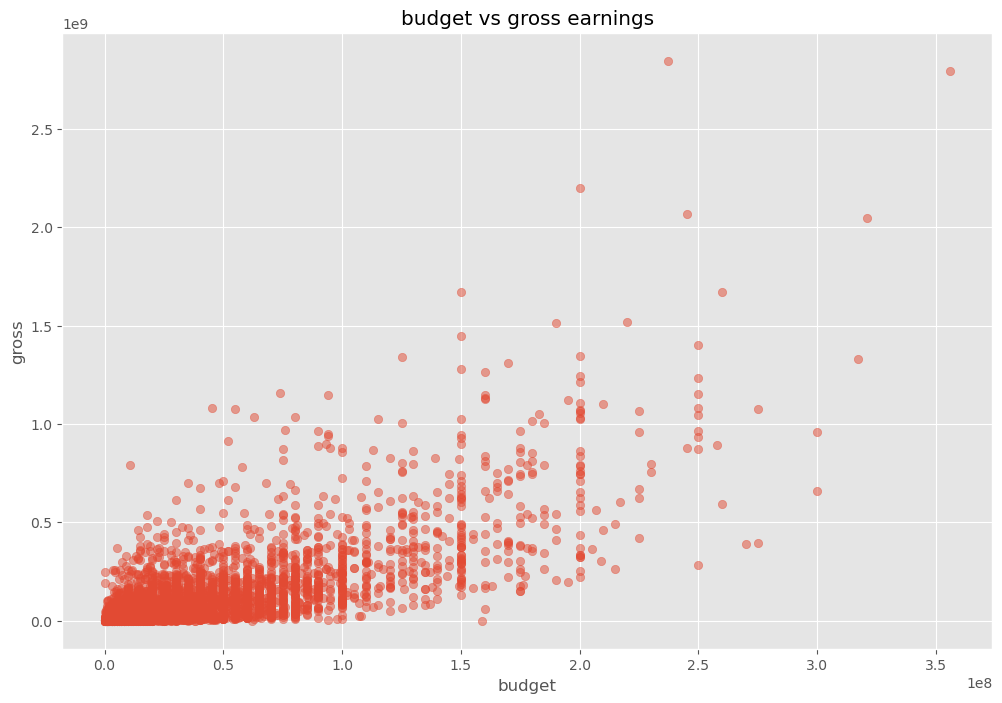

In [18]:
#budget vs gross earnings, do greataer budget give more revenue ?
plt.scatter(df['budget'],df['gross'], alpha=0.5)
plt.title("budget vs gross earnings")
plt.xlabel("budget")
plt.ylabel("gross")
plt.show()

In [19]:
df[['budget','gross']].corr()

,budget,gross
budget,1.000000,0.740395
gross,0.740395,1.000000


<Axes: xlabel='gross', ylabel='budget'>

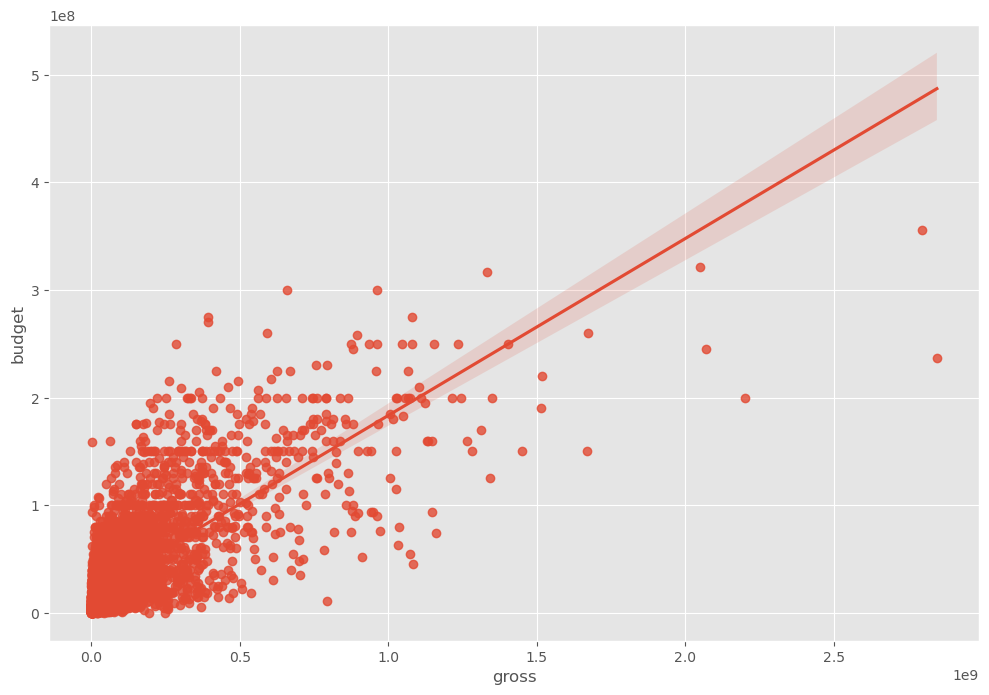

In [20]:
sns.regplot(x="gross", y="budget",data=df)

In [21]:
# highly related. so most of the high budget films do give rise to high revenue.!

In [22]:
# to which genre do the high revenue films belong to?

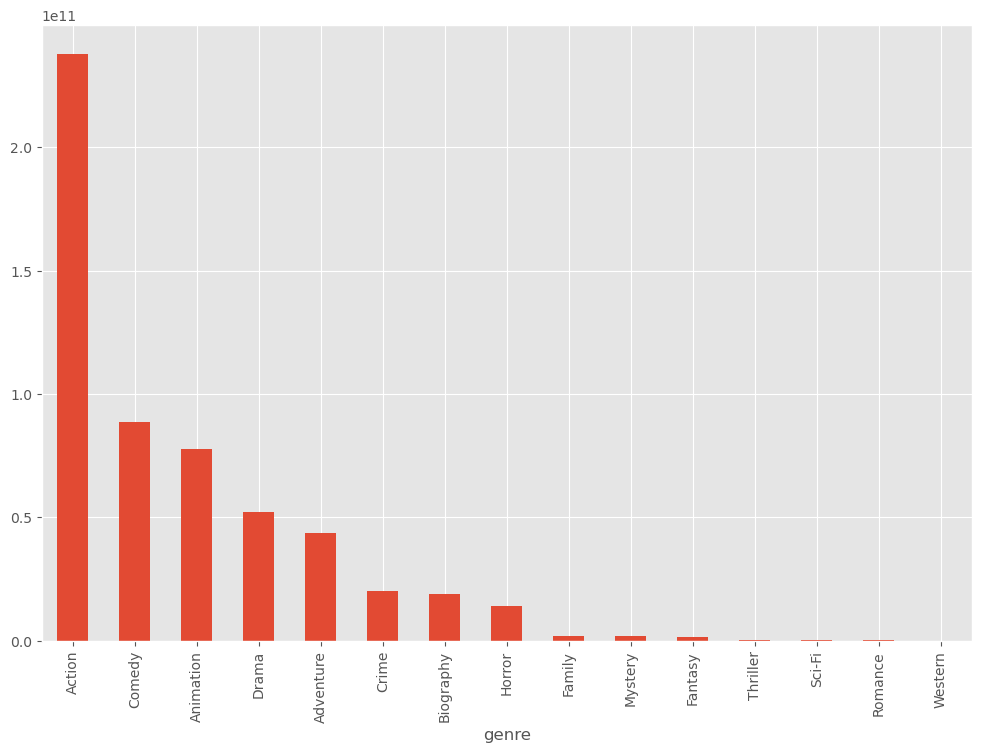

In [23]:
genre_gross=df.groupby('genre')['gross'].sum().sort_values(ascending=False)
genre_gross.plot(kind='bar')
plt.tile=("revenue by genre")
plt.show()

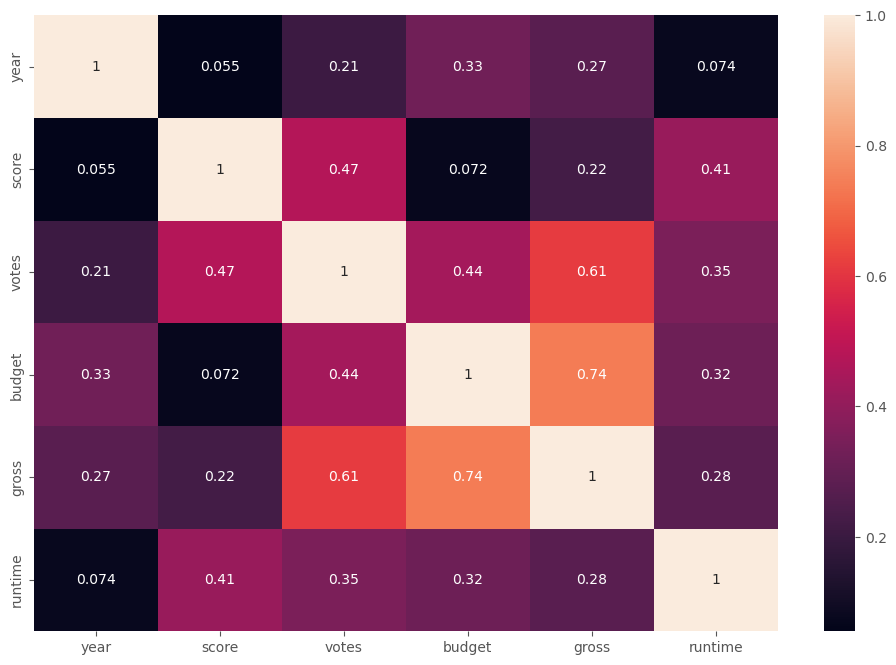

In [24]:
#find the correlation betwwen the diffrent variables by correlation heatmaps
correlation=df.corr(numeric_only=True)
sns.heatmap(correlation,annot=True)
plt.title="correlation heatmap matrix"
plt.show()

In [25]:
# the (gross,budget) and (votes,gross) have a positive corelation among the all.

In [26]:
#top 10 movies with  highest revenue

In [27]:
top_movies=df.sort_values(by='gross',ascending=False).head(10)
print(top_movies[['name','gross','budget','genre']])

                                            name         gross       budget  \
5445                                      Avatar  2.847246e+09  237000000.0   
7445                           Avengers: Endgame  2.797501e+09  356000000.0   
3045                                     Titanic  2.201647e+09  200000000.0   
6663  Star Wars: Episode VII - The Force Awakens  2.069522e+09  245000000.0   
7244                      Avengers: Infinity War  2.048360e+09  321000000.0   
7480                               The Lion King  1.670728e+09  260000000.0   
6653                              Jurassic World  1.670516e+09  150000000.0   
6043                                The Avengers  1.518816e+09  220000000.0   
6646                                   Furious 7  1.515341e+09  190000000.0   
7494                                   Frozen II  1.450027e+09  150000000.0   

          genre  
5445     Action  
7445     Action  
3045      Drama  
6663     Action  
7244     Action  
7480  Animation  
6653

In [28]:
# checking if the higher rate films generate high income

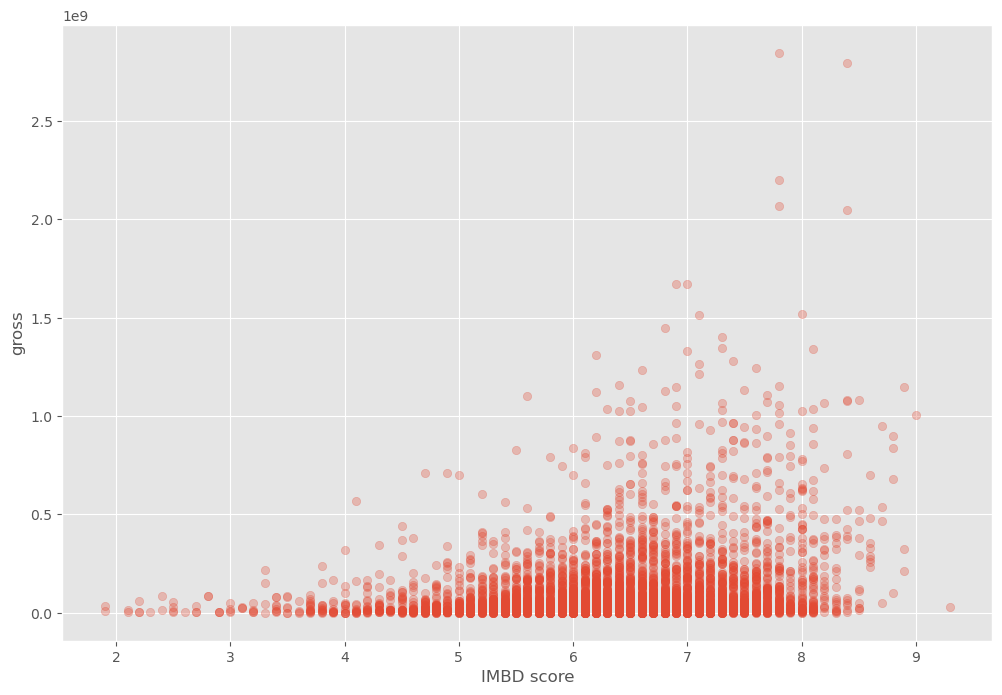

In [29]:
plt.scatter(df['score'],df['gross'],alpha=0.3)

plt.xlabel("IMBD score")
plt.ylabel("gross")
plt.title="score vs gross"

plt.show()
            

In [30]:
# the scatter plot shows the wwak positive correlation, 
#while some of the highly rated movies generate high income, 
#it might not be applicable to all the movies, some of the mid rated movies also generate high income. 
#so the rating might not be the sole factor and many other factors may involved in generating the high revenue.

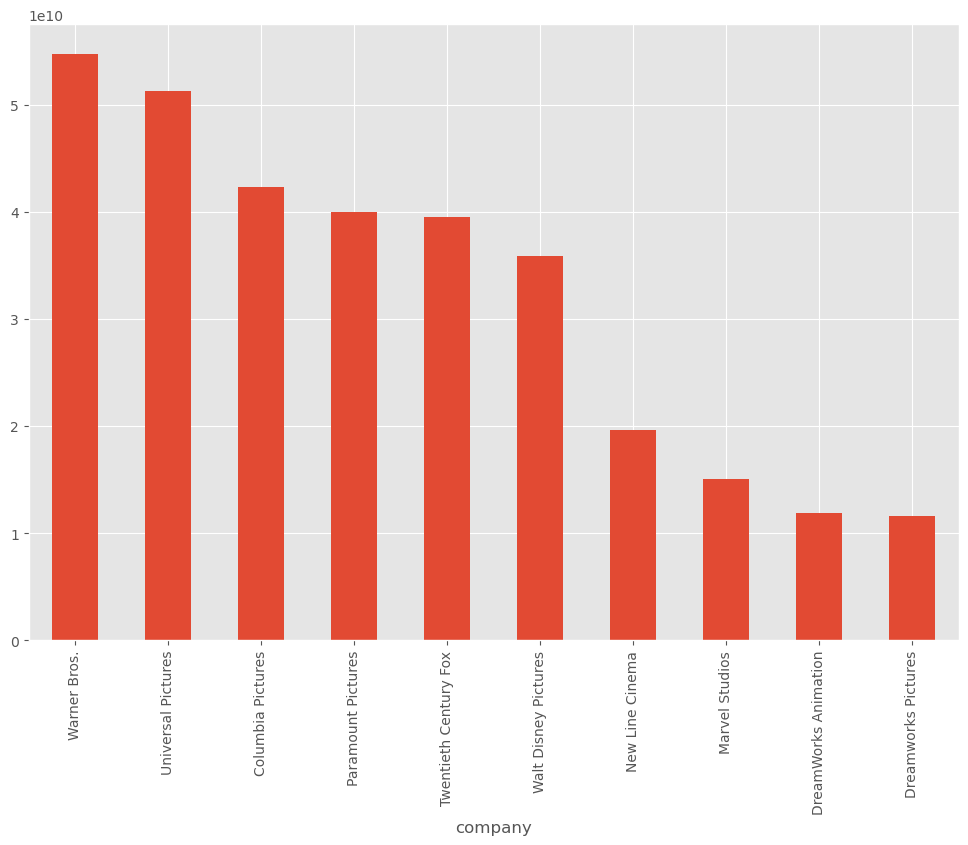

In [31]:
# top 10  production companies
production_companies=df.groupby('company')['gross'].sum().sort_values(ascending=False).head(10)
production_companies.plot(kind='bar')

plt.title="top 10 production companies"
plt.show()


In [32]:
#converting the categorical columns to numeric, so that we can use these columns for understanding the correlation

In [33]:
cat_columns=df.select_dtypes(['category']).columns

In [34]:
df[cat_columns]=df[cat_columns].apply(lambda x:x.cat.codes)
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime,correctyear
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0,1980
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0,1980
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0,1980
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0,1980
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7648,Bad Boys for Life,R,Action,2020,"January 17, 2020 (United States)",6.6,140000.0,Adil El Arbi,Peter Craig,Will Smith,United States,90000000.0,426505244.0,Columbia Pictures,124.0,"17, 2"
7649,Sonic the Hedgehog,PG,Action,2020,"February 14, 2020 (United States)",6.5,102000.0,Jeff Fowler,Pat Casey,Ben Schwartz,United States,85000000.0,319715683.0,Paramount Pictures,99.0,"14,"
7650,Dolittle,PG,Adventure,2020,"January 17, 2020 (United States)",5.6,53000.0,Stephen Gaghan,Stephen Gaghan,Robert Downey Jr.,United States,175000000.0,245487753.0,Universal Pictures,101.0,"17, 2"
7651,The Call of the Wild,PG,Adventure,2020,"February 21, 2020 (United States)",6.8,42000.0,Chris Sanders,Michael Green,Harrison Ford,Canada,135000000.0,111105497.0,20th Century Studios,100.0,"21,"


In [35]:
# how movie revenue is distributed across the diffrent movie ratings

C:\Users\Tanusree\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 93.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Tanusree\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 77.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Tanusree\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 22.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Tanusree\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 63.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\Tanusree\anaconda3\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 83.8

<Axes: xlabel='rating', ylabel='gross'>

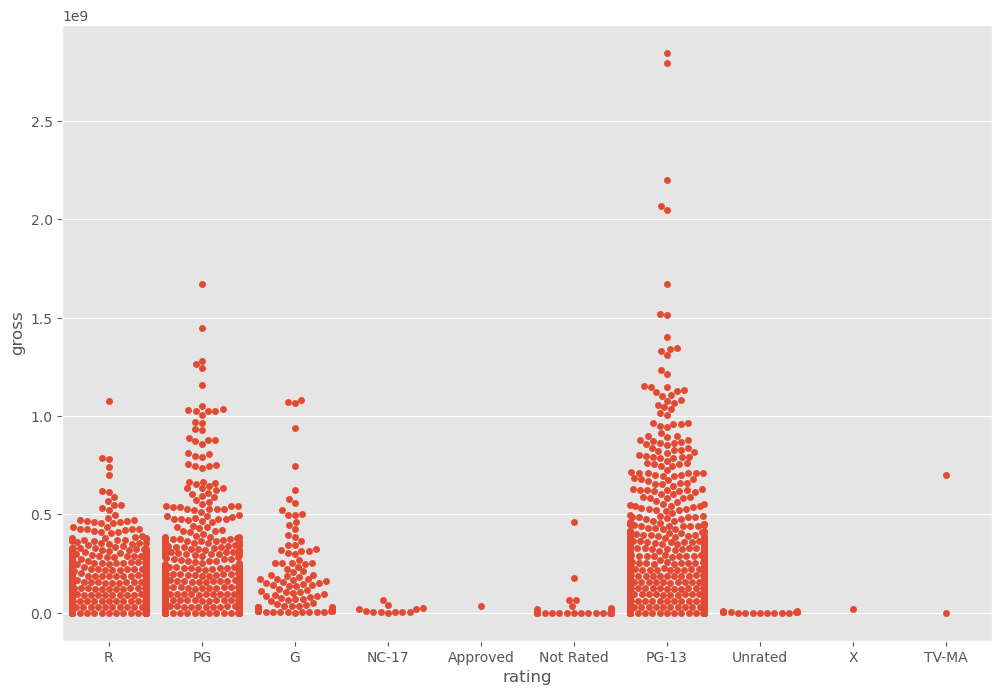

In [36]:
sns.swarmplot(x='rating',y='gross',data=df)

In [37]:
#votes vs gross revenue

In [42]:
df[['votes','gross']].corr()

,votes,gross
votes,1.000000,0.614904
gross,0.614904,1.000000


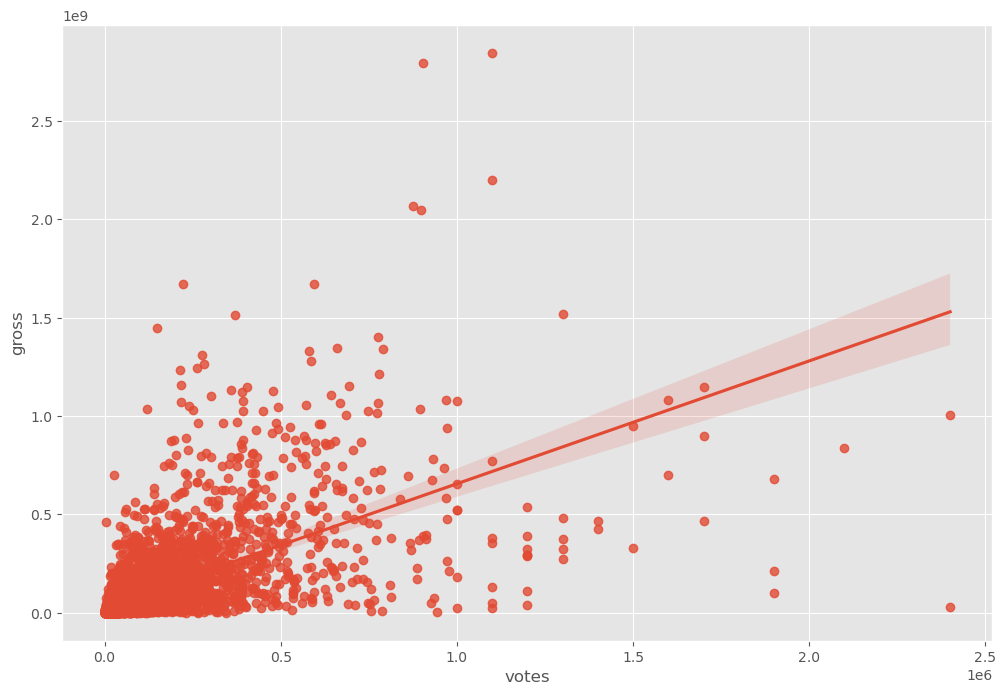

In [43]:
sns.regplot(x='votes',y='gross',data=df)
plt.title="votes vs gross"
plt.show()

In [48]:
#whcih top 10 countries generate the highest revenue

In [49]:
country_gross = df.groupby('country')['gross'].sum().sort_values(ascending=False)

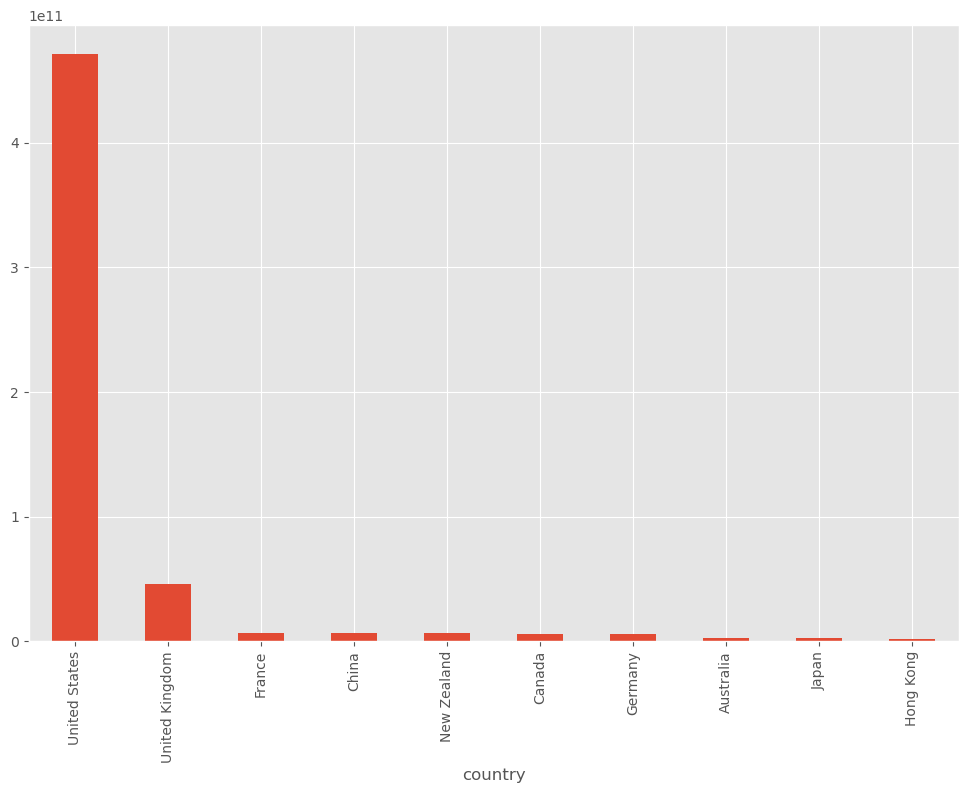

In [50]:
country_gross.head(10).plot(kind='bar')
plt.xlabel=("country")
plt.ylabel=("gross")
plt.title="top 10 highst revenue gen countries"
plt.show()